In [1]:
from random import choice
import os
import seaborn as sns
from adjustText import adjust_text
import argparse
import json
import numpy as np
import pandas as pd
import sys
import tensorflow as tf
from datetime import datetime
import matplotlib.pyplot as plt
import plotly.express as px
import dash
import dash_core_components as dcc
import dash_html_components as html
from dash.dependencies import Input, Output
import warnings
warnings.filterwarnings('ignore')
from colorama import init, Fore, Style
import plotly.offline as offline
import matplotlib.cm as cm
import matplotlib
from matplotlib.lines import Line2D

C:\Users\afuentesj\AppData\Local\Temp\ipykernel_26584\4098590381.py:15: UserWarning: 
The dash_core_components package is deprecated. Please replace
`import dash_core_components as dcc` with `from dash import dcc`
  import dash_core_components as dcc
C:\Users\afuentesj\AppData\Local\Temp\ipykernel_26584\4098590381.py:16: UserWarning: 
The dash_html_components package is deprecated. Please replace
`import dash_html_components as html` with `from dash import html`
  import dash_html_components as html


**En este análisis se van a implementar y comparar los siguientes tipos de rankings:**
    
    
1.	**Valor de Skill**: Este campo contiene valores continuos que son devueltos por el algoritmo de Trueskill. Para calcular este ranking, se considera la relación:
$\frac{\text{skill partido}}{\text{skill partido contrario}}$

2.	**Valor de Skill Reindexado**: Hasta el momento, hemos utilizado el ranking basado en el valor de "skill" reindexado. Ordenando los valores de "skill" de mayor a menor, se asigna un nuevo ranking de 1 a 220 (la cantidad total de propuestas). Sobre este nuevo ranking, se aplica la relación $\frac{\text{ranking partido}}{\text{ranking partido contrario}}$. Esta metodología se basó en la implementación utilizada en el archivo de la Figura 4 del repositorio de Nominate original.

3. **Win rate**: Se calcula como el número de veces que una opción ha sido elegida dividido por el número total de veces que se ha presentado esa combinación de opciones


## Lectura datos

In [2]:
# Asignación de los argumentos a variables correspondientes
DATASET = 'chile'
# Leer metadatos de usuarios desde un archivo CSV
userMetadata = pd.read_csv(f'../data/data_people_dump_{DATASET}.csv')

# Cargar el archivo CSV de coordenadas las propuestas
coordsP = pd.read_csv('results/coordsP/chile_04_01_2024_16_46_41.csv')

# Cargar el archivo TSV de etiquetas de coordenadas
labels_coords = pd.read_csv(f'../data/labels/chile.tsv', delimiter='\t').rename(columns={'id': 'option_id'})

# Combinar (merge) los DataFrames coordsP y labels_coords en base a la columna 'option_id'
coordsP = coordsP.merge(labels_coords, on='option_id')

# Cargar el archivo CSV de coordenadas Usuarios
coordsU = pd.read_csv('results/coordsU/chile_04_01_2024_16_46_41.csv')
coordsU = pd.merge(userMetadata, coordsU,on='uuid')



In [3]:
ranking = pd.read_excel('results/Ranking_propuestas_trueskill_primerciclo.xlsx')
ranking =ranking.rename({'id':'option_id'},axis=1)
ranking_coords = coordsP.merge(ranking,on='option_id')

In [4]:
def graficar_usuario_propuesta(coordsP,lista_iz,lista_der):
    # Crea un diccionario que mapee los nombres a 'square' (cuadrado) o 'diamond' (rombo)
    symbols_dict = {name: 'square' for name in lista_der}
    symbols_dict.update({name: 'diamond' for name in lista_iz})

    # Asigna 'circle' a los nombres que no están en las listas 'izquierda' ni 'derecha'
    symbols_dict.update({name: 'circle' for name in coordsP['short_name'] if name not in lista_iz and name not in lista_der})
    # Asigna 'circle' a los nombres que no están en las listas 'izquierda' ni 'derecha'
    coordsP['symbol'] = coordsP['short_name'].map(symbols_dict)

    # Define el tamaño de los símbolos
    symbol_size = [2 if symbol in ('square', 'diamond') else 0.5 for symbol in coordsP['symbol']]

    # Define los colores de los puntos como una nueva columna "colors" en coordsP
    coordsP['colors'] = ['blue' if symbol == 'square' else 'red' if symbol == 'diamond' else 'grey' for symbol in coordsP['symbol']]


    #Se agrega información de ranking
    coordsP['ranking'] = 'No ranking'

    for index, row in coordsP.iterrows():
        short_name = row['short_name']

        if short_name in lista_iz:
            coordsP.at[index, 'ranking'] = lista_iz.index(short_name)
        elif short_name in lista_der:
            coordsP.at[index, 'ranking'] = lista_der.index(short_name)

    coordsP = coordsP.sort_values(by='colors')

    colores = ["red", "blue"]
    iz = coordsU[(coordsU['politica'] >= 0) & (coordsU['politica'] <= 4)]
    der = coordsU[(coordsU['politica'] >= 6) & (coordsU['politica'] <= 10)]
    iz ['Political parties'] = 'Far-left [0,4]'
    der ['Political parties'] = 'Far-right [6,10]'
    extremos = pd.concat([iz,der],axis=0)

    # Crear una figura y subgráficos con tamaño fijo
    fig, axs = plt.subplots(figsize=(8, 8), gridspec_kw={'bottom': 0.15, 'left': 0.15, 'right': 0.85, 'top': 0.9})


    # Graficar el gráfico de densidad con jointplot
    sns.kdeplot(data=extremos, x='z2', y='z1', hue='Political parties', palette=colores,
                fill=True, alpha=0.6, ax=axs)

    # Graficar el gráfico de dispersión
    # Graficar el gráfico de dispersión
    scatter = sns.scatterplot(data=coordsP, x="z2", y="z1", hue='colors', palette=['blue', 'grey', 'red'], 
                          size='symbol', sizes={'circle': 50, 'square': 150, 'diamond': 150}, ax=axs)


    # Añadir texto con el nombre corto y el ranking a cada punto azul y rojo
    for index, row in coordsP.iterrows():
        short_name = row['short_name']
        ranking = row['ranking']
        x, y = row['z2'], row['z1']

        # Añadir texto solo a puntos azules y rojos
        if row['colors'] in ['blue', 'red']:
            # Ajusta el desplazamiento en x (puedes cambiar el valor según tus preferencias)
            x_offset = 0.02
            axs.text(x + x_offset, y, f'{ranking+1}', fontsize=10, ha='left', va='center')



    # Personalizar leyenda con etiquetas


    labels = ['Left','Right','Others']
    colors = ['red', 'blue', 'gray']
    handles = [Line2D([0], [0], marker='o', color=color, label=label, markersize=8,linestyle='None') for color, label in zip(colors, labels)]
    axs.legend(handles=handles, labels=labels)

    # Mostrar la figura
    plt.xlim(-0.05,1.05)
    plt.tight_layout()
    axs.axvline(x=0.5, color='gray', linestyle='--')
     
    plt.xlabel('Political Dimension 1')
    plt.ylabel('Political Dimension 2')


    # Dibujar una línea horizontal punteada en y=0.5
    axs.axhline(y=0.5, color='gray', linestyle='--')
    plt.show()
    
    
def reescalar(ranking, nuevo_min, nuevo_max):
    return (ranking - ranking.min()) / (ranking.max() - ranking.min()) * (nuevo_max - nuevo_min) + nuevo_min



def graficar_usuario_propuesta_v2(coordsP, ranking, coordsU):
    coordsP['ranking_rescaled'] = reescalar(coordsP[ranking], 0, 220)
    # Define los colores de los puntos como una nueva columna "colors" en coordsP
    coordsP['colors'] = coordsP['ranking_rescaled']*-1

    # Se agrega información de ranking
    coordsP['ranking'] = coordsP[ranking]

    iz = coordsU[(coordsU['politica'] >= 0) & (coordsU['politica'] <= 4)]
    der = coordsU[(coordsU['politica'] >= 6) & (coordsU['politica'] <= 10)]
    iz['Political parties'] = 'Far-left [0,4]'
    der['Political parties'] = 'Far-right [6,10]'
    extremos = pd.concat([iz, der], axis=0)

    # Crear una figura y subgráficos
    fig, axs = plt.subplots(figsize=(12, 8))

    # Obtener la paleta de colores de azul a rojo
    colores = sns.color_palette("RdBu_r", n_colors=len(coordsP['colors']))
    cm = plt.cm.get_cmap("RdBu_r")

    # Graficar el gráfico de densidad con jointplot
    sns.kdeplot(
        data=extremos,
        x='z2',
        y='z1',
        hue='Political parties',
        palette=['red', 'blue'],
        fill=True,
        alpha=0.6,
        ax=axs
    )

    # Graficar el gráfico de dispersión con la paleta de colores
    sc = sns.scatterplot(
        data=coordsP,
        x="z2",
        y="z1",
        hue='colors',
        palette=colores,
        s=100,
        ax=axs
    )

    # Añadir texto con el nombre corto y el ranking a cada punto azul y rojo
    for index, row in coordsP.iterrows():
        short_name = row['short_name_x']
        ranking = row['ranking']
        x, y = row['z2'], row['z1']

        # Añadir texto solo a puntos azules y rojos
        x_offset = 0.02
        axs.text(x + x_offset, y, f'{ranking+1}', fontsize=10, ha='left', va='center')

    # Añadir barra de color continua
    norm = plt.Normalize(coordsP['colors'].min(), coordsP['colors'].max())
    sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
    sm.set_array([])
    cbar = axs.figure.colorbar(sm, ax=axs, pad=0.1)
    cbar.set_label('Left-Right Spectrum', fontsize=12)

    # Añadir etiquetas personalizadas
    cbar.ax.set_yticklabels(['','Right', '','','','','','','Left',''])

    # Mostrar la figura
    plt.xlim(-0.05, 1.05)
    #plt.tight_layout()
    plt.legend([])  # Eliminar la leyenda
    axs.axvline(x=0.5, color='gray', linestyle='--')
    
    plt.xlabel('Political Dimension 1')
    plt.ylabel('Political Dimension 2')
 

    # Dibujar una línea horizontal punteada en y=0.5
    axs.axhline(y=0.5, color='gray', linestyle='--')
    plt.show()
    

# Skill indexado
### TOP 5

In [4]:
from tabulate import tabulate
from IPython.display import display, HTML
def display_side_by_side(dfs: list, captions: list):
    """Display tables side by side to save vertical space
    Input:
        dfs: list of pandas.DataFrame
        captions: list of table captions
    """
    output = ""
    combined = dict(zip(captions, dfs))
    for caption, df in combined.items():
        df_html = df.style.set_table_attributes("style='display:inline'").set_caption(caption)._repr_html_()
        output += df_html
        output += "\xa0\xa0\xa0"
    display(HTML(output))


In [5]:
from tabulate import tabulate
from IPython.display import display, HTML
def display_side_by_side(dfs: list, captions: list):
    """Display tables side by side to save vertical space
    Input:
        dfs: list of pandas.DataFrame
        captions: list of table captions
    """
    output = ""
    combined = dict(zip(captions, dfs))
    for caption, df in combined.items():
        df_html = df.style.set_table_attributes("style='display:inline'").set_caption(caption)._repr_html_()
        output += df_html
        output += "\xa0\xa0\xa0"
    display(HTML(output))

# Define la lista de nombres que deben tener el símbolo de cuadrado (square)
derecha_top5 = list(ranking_coords.sort_values("ranking_derecha_sort", ascending=True)['short_name_x'][0:5])

# Define la lista de nombres que deben tener el símbolo de rombo (diamond)
izquierda_top5 = list(ranking_coords.sort_values("ranking_izquierda_sort", ascending=True)['short_name_x'][0:5])

# Crear DataFrames para las listas
df_derecha = pd.DataFrame({'Propuesta': derecha_top5})
df_izquierda = pd.DataFrame({ 'Propuesta': izquierda_top5})
df_izquierda.index += 1  # Sumar uno a los índices
df_derecha.index += 1  # Sumar uno a los índices


# Imprime los DataFrames usando tabulate
display_side_by_side([df_derecha, df_izquierda], ['Ranking Derecha', 'Ranking Izquierda'])

#graficar_usuario_propuesta(coordsP,izquierda_top5 ,derecha_top5 )

,Propuesta
1,Contribuciones
2,Enfermedades Catastróficas
3,Narcotráfico
4,Sistema Electoral
5,Dieta Parlamentaria
,Propuesta
1,Nueva Constitución
2,Asamblea Constituyente
3,Agua
4,Derechos Humanos


<Figure size 800x800 with 0 Axes>

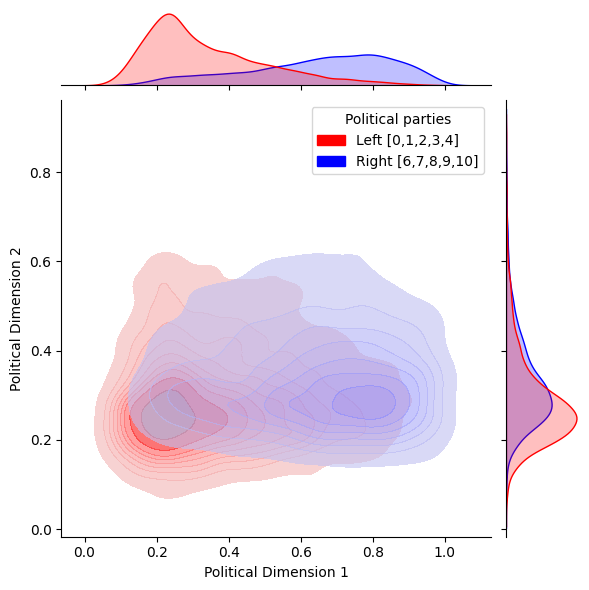

In [10]:
colores = ["red", "blue"]
iz = coordsU[(coordsU['politica'] >= 0) & (coordsU['politica'] <= 4)]
der = coordsU[(coordsU['politica'] >= 6) & (coordsU['politica'] <= 10)]
iz ['Political parties'] = 'Left [0,1,2,3,4]'
der ['Political parties'] = 'Right [6,7,8,9,10]'
extremos = pd.concat([iz,der],axis=0)

# Figura 4
plt.figure(figsize=(8, 8))
extremo=sns.jointplot(data=extremos, x='z2', y='z1',hue='Political parties', kind='kde',palette=colores,
              fill=True, joint_kws={'alpha': 0.6, 'shade': True, 'shade_lowest': False})
extremo.set_axis_labels('Political Dimension 1', 'Political Dimension 2')
ax = plt.gca()
plt.show()


In [6]:
def graficar_usuario_propuesta_v1(coordsP, lista_iz, lista_der, coordsU):
    # Crea un diccionario que mapee los nombres a 'square' (cuadrado) o 'diamond' (rombo)
    symbols_dict = {name: 'square' for name in lista_der}
    symbols_dict.update({name: 'diamond' for name in lista_iz})

    # Asigna 'circle' a los nombres que no están en las listas 'izquierda' ni 'derecha'
    symbols_dict.update({name: 'circle' for name in coordsP['short_name'] if name not in lista_iz and name not in lista_der})
    coordsP['symbol'] = coordsP['short_name'].map(symbols_dict)

    # Define el tamaño de los símbolos (no directamente usado aquí, pero se deja para referencia)
    symbol_size = [2 if symbol in ('square', 'diamond') else 0.5 for symbol in coordsP['symbol']]

    # Define los colores de los puntos
    coordsP['colors'] = ['blue' if symbol == 'square' else 'red' if symbol == 'diamond' else 'grey' for symbol in coordsP['symbol']]

    # Se agrega información de ranking
    coordsP['ranking'] = 'No ranking'
    for index, row in coordsP.iterrows():
        short_name = row['short_name']
        if short_name in lista_iz:
            coordsP.at[index, 'ranking'] = lista_iz.index(short_name)
        elif short_name in lista_der:
            coordsP.at[index, 'ranking'] = lista_der.index(short_name)

    coordsP = coordsP.sort_values(by='colors')

    colores = ["red", "blue"]
    iz = coordsU[(coordsU['politica'] >= 0) & (coordsU['politica'] <= 4)]
    der = coordsU[(coordsU['politica'] >= 6) & (coordsU['politica'] <= 10)]
    iz['Political parties'] = 'Far-left [0,4]'
    der['Political parties'] = 'Far-right [6,10]'
    extremos = pd.concat([iz, der], axis=0)

    # Crear el jointplot con distribución marginal
    # kind='kde' generará el gráfico conjunto y las distribuciones marginales
    extremo = sns.jointplot(
        data=extremos,
        x='z2',
        y='z1',
        hue='Political parties',
        kind='kde',
        palette=colores,
        fill=True,
        joint_kws={'alpha': 0.6, 'shade': True, 'shade_lowest': False},
        height=8
    )

    # Agregar el scatterplot de coordsP sobre el gráfico conjunto
    # Usamos extremo.ax_joint para acceder a los ejes centrales del jointplot
    sns.scatterplot(
        data=coordsP,
        x="z2",
        y="z1",
        hue='colors',
        palette=['blue', 'grey', 'red'],
        size='symbol',
        sizes={'circle': 50, 'square': 150, 'diamond': 150},
        ax=extremo.ax_joint,
        legend=False  # legend ya está manejada por hue del jointplot
    )

    # Añadir texto con el ranking a cada punto de color azul y rojo
    for index, row in coordsP.iterrows():
        short_name = row['short_name']
        ranking = row['ranking']
        x, y = row['z2'], row['z1']
        # Añadir texto solo a puntos azules y rojos
        if row['colors'] in ['blue', 'red']:
            x_offset = 0.02
            extremo.ax_joint.text(x + x_offset, y, f'{ranking+1}', fontsize=10, ha='left', va='center')

    # Ajustar los límites de los ejes principales
    extremo.ax_joint.set_xlim(-0.05, 1.05)

    # Agregar líneas punteadas en x=0.5 y y=0.5
    extremo.ax_joint.axvline(x=0.5, color='gray', linestyle='--')
    extremo.ax_joint.axhline(y=0.5, color='gray', linestyle='--')

    # Etiquetas de ejes
    extremo.set_axis_labels('Political Dimension 1', 'Political Dimension 2')

    # Si se quiere personalizar la leyenda manualmente, se puede hacer así:
    # (Descomentariar si se desea una leyenda personalizada)
    # labels = ['Left','Right','Others']
    # colors = ['red', 'blue', 'gray']
    # handles = [Line2D([0], [0], marker='o', color=color, label=label, markersize=8, linestyle='None') for color, label in zip(colors, labels)]
    # extremo.ax_joint.legend(handles=handles, labels=labels, loc='upper right')

    plt.show()

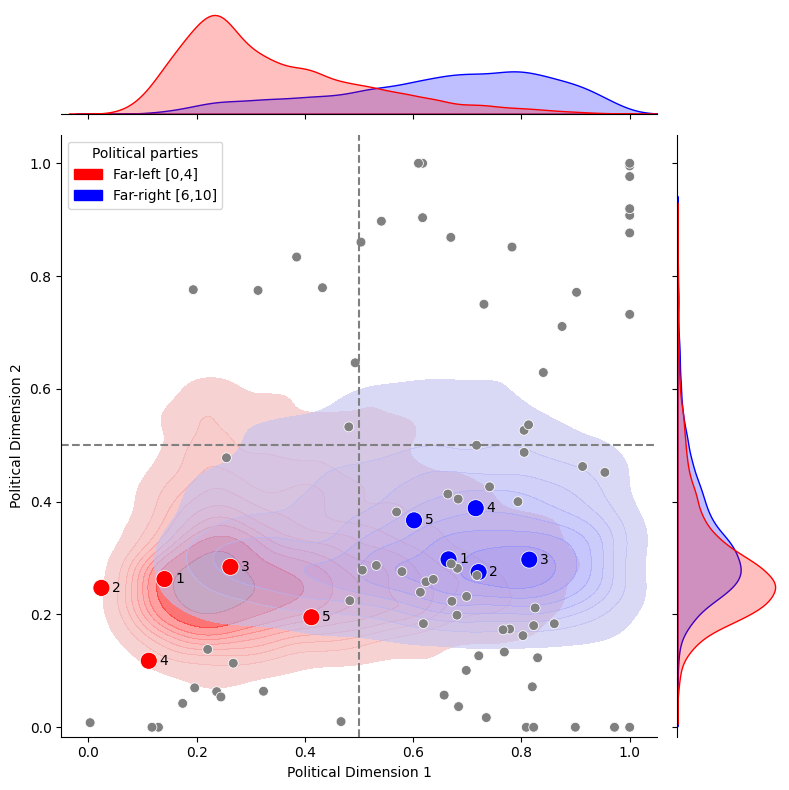

In [13]:
graficar_usuario_propuesta_v1(coordsP,izquierda_top5 ,derecha_top5, coordsU )

In [9]:
def graficar_usuario_propuesta_v2(coordsP, lista_iz, lista_der, coordsU):
    # Crea un diccionario que mapee los nombres a 'square' (cuadrado) o 'diamond' (rombo)
    symbols_dict = {name: 'square' for name in lista_der}
    symbols_dict.update({name: 'diamond' for name in lista_iz})

    # Asigna 'circle' a los nombres que no están en las listas 'izquierda' ni 'derecha'
    symbols_dict.update({name: 'circle' for name in coordsP['short_name'] if name not in lista_iz and name not in lista_der})
    coordsP['symbol'] = coordsP['short_name'].map(symbols_dict)

    # Define los colores de los puntos
    coordsP['colors'] = ['blue' if symbol == 'square' else 'red' if symbol == 'diamond' else 'grey' for symbol in coordsP['symbol']]

    # Se agrega información de ranking
    coordsP['ranking'] = 'No ranking'
    for index, row in coordsP.iterrows():
        short_name = row['short_name']
        if short_name in lista_iz:
            coordsP.at[index, 'ranking'] = lista_iz.index(short_name)
        elif short_name in lista_der:
            coordsP.at[index, 'ranking'] = lista_der.index(short_name)

    coordsP = coordsP.sort_values(by='colors')

    # Cambiamos las etiquetas a "Left [0,1,2,3,4]" y "Right [6,7,8,9,10]"
    iz = coordsU[(coordsU['politica'] >= 0) & (coordsU['politica'] <= 4)]
    der = coordsU[(coordsU['politica'] >= 6) & (coordsU['politica'] <= 10)]
    iz['Political parties'] = 'Left [0,1,2,3,4]'
    der['Political parties'] = 'Right [6,7,8,9,10]'
    extremos = pd.concat([iz, der], axis=0)

    colores = ["red", "blue"]

    # Crear el jointplot con distribución marginal
    extremo = sns.jointplot(
        data=extremos,
        x='z2',
        y='z1',
        hue='Political parties',
        kind='kde',
        palette=colores,
        fill=True,
        joint_kws={'alpha': 0.6, 'shade': True, 'shade_lowest': False},
        height=8
    )

    # Agregar el scatterplot de coordsP sobre el gráfico conjunto
    sns.scatterplot(
        data=coordsP,
        x="z2",
        y="z1",
        hue='colors',
        palette=['blue', 'grey', 'red'],
        size='symbol',
        sizes={'circle': 50, 'square': 150, 'diamond': 150},
        ax=extremo.ax_joint,
        legend=False
    )

    # Añadir texto con el ranking a cada punto azul y rojo
    for index, row in coordsP.iterrows():
        short_name = row['short_name']
        ranking = row['ranking']
        x, y = row['z2'], row['z1']
        if row['colors'] in ['blue', 'red']:
            x_offset = 0.02
            extremo.ax_joint.text(x + x_offset, y, f'{ranking+1}', fontsize=10, ha='left', va='center')

    # Ajustar los límites de los ejes principales
    extremo.ax_joint.set_xlim(-0.05, 1.05)

    # Agregar líneas punteadas en x=0.5 y y=0.5
    extremo.ax_joint.axvline(x=0.5, color='gray', linestyle='--')
    extremo.ax_joint.axhline(y=0.5, color='gray', linestyle='--')

    # Etiquetas de ejes
    extremo.set_axis_labels('Political Dimension 1', 'Political Dimension 2')

    # Añadir leyenda en la otra esquina (por ejemplo, esquina superior izquierda)
    # Leyenda personalizada para Left, Right, Others
    labels = ['Left', 'Right', 'Others']
    colors = ['red', 'blue', 'gray']
    handles = [Line2D([0], [0], marker='o', color=color, label=label, markersize=8, linestyle='None') 
               for color, label in zip(colors, labels)]
    extremo.ax_joint.legend(handles=handles, labels=labels, loc='upper left')
    plt.savefig("Paper images/paper_fig_2c.svg")
    plt.show()

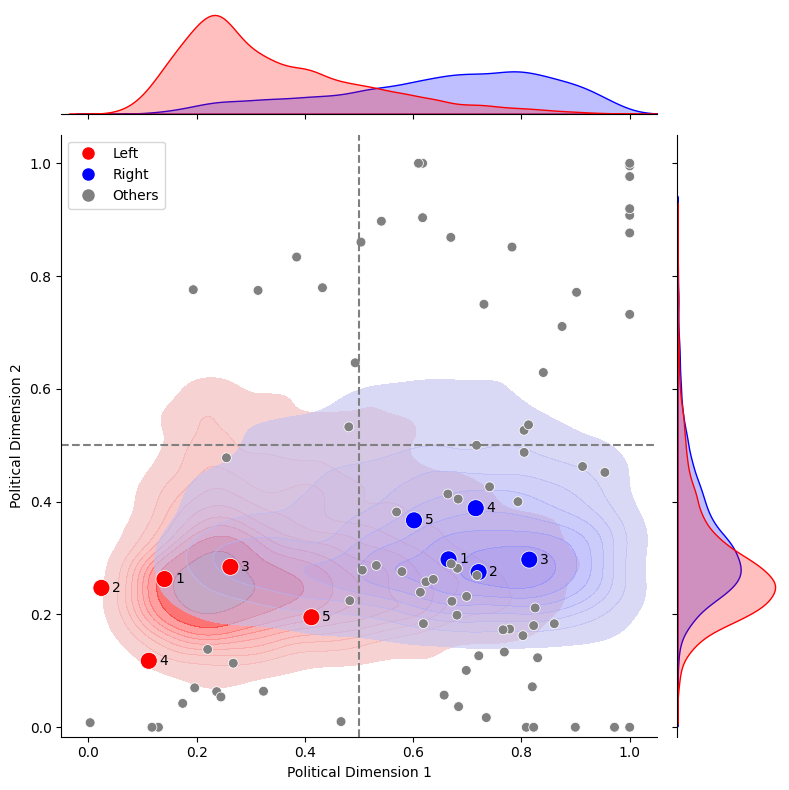

In [10]:
graficar_usuario_propuesta_v2(coordsP,izquierda_top5 ,derecha_top5, coordsU )